In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("marvel_raw_dataset.csv")

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
df["Character_Name"] = df["Character_Name"].str.strip()

In [5]:
df["Gender"] = df["Gender"].str.capitalize()
df["Role"] = df["Role"].str.capitalize()
df["Team"] = df["Team"].str.capitalize()


In [6]:
df.fillna({
    "Character_Name": "Unknown",
    "Gender": "Unknown",
    "Role": "Unknown",
    "Team": "Unknown"
}, inplace=True)

In [7]:
df["Power_Level"] = pd.to_numeric(df["Power_Level"], errors="coerce")
df["First_Appearance_Year"] = pd.to_numeric(df["First_Appearance_Year"], errors="coerce")
df["Popularity_Score"] = pd.to_numeric(df["Popularity_Score"], errors="coerce")

In [8]:
df = df[df["Power_Level"] <= 100]
df = df[df["Popularity_Score"] <= 10]

In [9]:
df.reset_index(drop=True, inplace=True)

In [10]:
if len(df) < 400:
    df = df.sample(n=400, replace=True, random_state=42)

print("Final Shape (After Expand):", df.shape)

Final Shape (After Expand): (400, 8)


In [11]:
df.to_csv("marvel_cleaned_dataset.csv", index=False)

In [12]:

df.head()

,Character_Name,Gender,Role,Universe,Power_Level,Team,First_Appearance_Year,Popularity_Score
102,GameRevolution,Male,Villain,MCU,82,Avengers,2022,7
270,Tomorrowland,Female,Hero,MCU,71,Solo,2022,5
106,Odin,Female,Hero,MCU,57,Solo,2019,9
71,FanSided,Male,Hero,MCU,93,Guardians,2015,3
188,Lionsgate,Female,Hero,MCU,97,Solo,2022,2


In [13]:
# Load datasets
before_df = pd.read_csv("marvel_raw_dataset.csv")
after_df = pd.read_csv("marvel_cleaned_dataset.csv")

# Take first 5 rows (for display like your image)
before_sample = before_df.head(5)
after_sample = after_df.head(5)

print("Old Data Frame")
display(before_sample)

print("New Data Frame")
display(after_sample)

Old Data Frame


,Character_Name,Gender,Role,Universe,Power_Level,Team,First_Appearance_Year,Popularity_Score
0,Forbes,Male,Supporting,MCU,67,Avengers,2013,3
1,Reception,Female,Supporting,MCU,61,Solo,2017,9
2,Flubber,Male,Villain,MCU,76,Solo,2021,3
3,Television,Female,Hero,MCU,76,Avengers,2018,7
4,Ultron,Male,Villain,MCU,50,Guardians,2015,1


New Data Frame


,Character_Name,Gender,Role,Universe,Power_Level,Team,First_Appearance_Year,Popularity_Score
0,GameRevolution,Male,Villain,MCU,82,Avengers,2022,7
1,Tomorrowland,Female,Hero,MCU,71,Solo,2022,5
2,Odin,Female,Hero,MCU,57,Solo,2019,9
3,FanSided,Male,Hero,MCU,93,Guardians,2015,3
4,Lionsgate,Female,Hero,MCU,97,Solo,2022,2


In [14]:
def style_df(df):
    return df.style.set_table_styles([
        {"selector": "th", "props": [("background-color", "#333"), ("color", "white"), ("font-size", "12pt")]},
        {"selector": "td", "props": [("font-size", "11pt")]}
    ])

print("Old Data Frame")
display(style_df(before_sample))

print("New Data Frame")
display(style_df(after_sample))

Old Data Frame


,Character_Name,Gender,Role,Universe,Power_Level,Team,First_Appearance_Year,Popularity_Score
0,Forbes,Male,Supporting,MCU,67,Avengers,2013,3
1,Reception,Female,Supporting,MCU,61,Solo,2017,9
2,Flubber,Male,Villain,MCU,76,Solo,2021,3
3,Television,Female,Hero,MCU,76,Avengers,2018,7
4,Ultron,Male,Villain,MCU,50,Guardians,2015,1


New Data Frame


,Character_Name,Gender,Role,Universe,Power_Level,Team,First_Appearance_Year,Popularity_Score
0,GameRevolution,Male,Villain,MCU,82,Avengers,2022,7
1,Tomorrowland,Female,Hero,MCU,71,Solo,2022,5
2,Odin,Female,Hero,MCU,57,Solo,2019,9
3,FanSided,Male,Hero,MCU,93,Guardians,2015,3
4,Lionsgate,Female,Hero,MCU,97,Solo,2022,2


In [16]:
! pip install dataframe-image

   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/6.7 MB 2.6 MB/s eta 0:00:03
   -------------- ------------------------- 2.4/6.7 MB 4.9 MB/s eta 0:00:01
   ----------------------- ---------------- 3.9/6.7 MB 6.0 MB/s eta 0:00:01
   -------------------------- ------------- 4.5/6.7 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 6.7/6.7 MB 6.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.8 MB ? eta -:--:--
   - -------------------------------------- 1.8/36.8 MB 10.0 MB/s eta 0:00:04
   --- ------------------------------------ 3.1/36.8 MB 7.9 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/36.8 MB 7.2 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/36.8 MB 7.0 MB/s eta 0:00:05
   ------- -----------------------

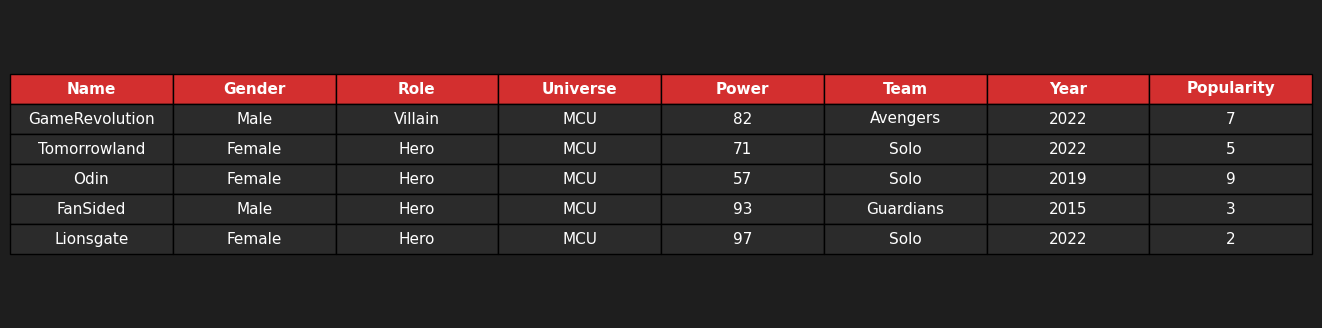

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("marvel_cleaned_dataset.csv")

# Rename columns (short & clean for display)
df.columns = [
    "Name", "Gender", "Role", "Universe",
    "Power", "Team", "Year", "Popularity"
]

df_sample = df.head(5)

# Create figure (BIG SIZE = better quality)
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

# Create table
table = ax.table(
    cellText=df_sample.values,
    colLabels=df_sample.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Apply colors
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#d32f2f')   # RED header (Marvel style)
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#2b2b2b')   # dark rows
        cell.set_text_props(color='white')

# Background
fig.patch.set_facecolor('#1e1e1e')

# Save high-quality image
plt.savefig("marvel_table_pro.png", bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor())
plt.show()